# MLP Binary Classification for Network Traffic Analysis

This notebook implements a Multi-Layer Perceptron (MLP) for binary classification of network traffic data. It trains on the baseline dataset and evaluates performance across three key datasets:

1. **FLATTEN-PCAPS** - Baseline dataset (original traffic)
2. **MANIPULATED-FLATTEN_42** - Traffic with manipulation techniques applied
3. **FRAGMENTED_42_150** - Traffic with fragmentation techniques applied

The analysis focuses on comparing False Negative Rates (FNR) per attack type to understand model robustness against evasion techniques.

In [1]:
## 1. Import Libraries

import time
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from util_functions import load_dataset

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("✅ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

2026-03-02 16:25:33.782502: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 16:25:33.783561: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 16:25:33.902177: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 16:25:35.265477: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

✅ Libraries imported successfully
TensorFlow version: 2.20.0


## 2. Configuration and Dataset Paths

In [2]:
# Configuration
EPOCHS = 100
BATCH_SIZE = 1024
LEARNING_RATE = 0.001

# Dataset paths
TRAFFIC_MANIPULATOR_BASE = '../TrafficManipulator-master/DATASETS/'

# Three target datasets for FNR comparison
TARGET_DATASETS = {
    'FLATTEN-PCAPS': {
        'name': 'Baseline',
        'description': 'Original traffic data (baseline)',
        'path': TRAFFIC_MANIPULATOR_BASE + 'FLATTEN-PCAPS/'
    },
    'MANIPULATED-FLATTEN_42': {
        'name': 'Manipulated',
        'description': 'Traffic with manipulation techniques (seed 42)',
        'path': TRAFFIC_MANIPULATOR_BASE + 'MANIPULATED-FLATTEN_42/'
    },
    'FRAGMENTED_42_150': {
        'name': 'Fragmented', 
        'description': 'Traffic with fragmentation techniques (seed 42, 150 fragments)',
        'path': TRAFFIC_MANIPULATOR_BASE + 'FRAGMENTED_42_150/'
    }
}

# Attack types for FNR analysis
ATTACK_TYPES = [
    '00-WebDDoS', '01-LDAP', '02-Portmap', '03-DNS', '04-UDPLag', 
    '05-NTP', '06-SNMP', '07-SSDP', '08-Syn', '09-TFTP', 
    '10-UDP', '11-NetBIOS', '12-MSSQL'
]

print("📋 MLP Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Learning Rate: {LEARNING_RATE}")

print(f"\n🎯 Target Datasets for FNR Analysis:")
for key, dataset in TARGET_DATASETS.items():
    print(f"   • {dataset['name']}: {dataset['description']}")

print(f"\n🎯 Attack Types: {len(ATTACK_TYPES)} attacks")

# Verify dataset paths
print("\n📁 Dataset Path Verification:")

for key, dataset in TARGET_DATASETS.items():    print(f"   {status} {dataset['name']}: {dataset['path']}")


📋 MLP Configuration:
   Epochs: 100
   Batch Size: 1024
   Learning Rate: 0.001

🎯 Target Datasets for FNR Analysis:
   • Baseline: Original traffic data (baseline)
   • Manipulated: Traffic with manipulation techniques (seed 42)
   • Fragmented: Traffic with fragmentation techniques (seed 42, 150 fragments)

🎯 Attack Types: 13 attacks

📁 Dataset Path Verification:


NameError: name 'status' is not defined

## 3. Load Training Data

In [ ]:
# Load baseline training and validation data
# baseline_path = TARGET_DATASETS['FLATTEN-PCAPS']['path']

baseline_path = "../TrafficManipulator-master/DATASETS/FLATTEN-PCAPS/"

print("📊 Loading training data...")
X_train, y_train = load_dataset(baseline_path + '*-train.hdf5')
X_val, y_val = load_dataset(baseline_path + '*-val.hdf5')

print(f"✅ Training data loaded successfully:")
print(f"   Training set: {X_train.shape} samples, {y_train.shape} labels")
print(f"   Validation set: {X_val.shape} samples, {y_val.shape} labels")
print(f"   Features per sample: {X_train.shape[1]}")

# Check class distribution
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)

print(f"\n📈 Class Distribution:")
print(f"   Training - Benign: {counts_train[0]}, Malicious: {counts_train[1]}")
print(f"   Validation - Benign: {counts_val[0]}, Malicious: {counts_val[1]}")
print(f"   Training Balance: {counts_train[1]/(counts_train[0]+counts_train[1])*100:.1f}% malicious")

📊 Loading training data...
✅ Training data loaded successfully:
   Training set: (897208, 21) samples, (897208,) labels
   Validation set: (83501, 21) samples, (83501,) labels
   Features per sample: 21

📈 Class Distribution:
   Training - Benign: 455373, Malicious: 441835
   Validation - Benign: 42081, Malicious: 41420
   Training Balance: 49.2% malicious


## 4. Build and Train MLP Model

In [ ]:
# Build MLP model
def build_mlp_model(input_shape, learning_rate=LEARNING_RATE):
    """Build and compile MLP model"""
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(128, activation='relu', name='dense1'),
        Dense(64, activation='relu', name='dense2'), 
        Dense(32, activation='relu', name='dense3'),
        Dense(1, activation='sigmoid', name='output')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build model
print("🏗️  Building MLP model...")
mlp_model = build_mlp_model(X_train.shape[1])
mlp_model.summary()

# Train model
print(f"\n🚀 Training model for {EPOCHS} epochs...")
start_time = time.time()

history = mlp_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

training_time = time.time() - start_time
print(f"✅ Training completed in {training_time:.2f} seconds")
print(f"   Average time per epoch: {training_time/EPOCHS:.2f} seconds")

# Save model
model_filename = 'mlp_flatten_binary_classification.h5'
mlp_model.save(model_filename)
print(f"💾 Model saved as: {model_filename}")

🏗️  Building MLP model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training model for 100 epochs...
Epoch 1/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9358 - loss: 0.1666 - val_accuracy: 0.9791 - val_loss: 0.0484
Epoch 2/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9836 - loss: 0.0542 - val_accuracy: 0.9867 - val_loss: 0.0479
Epoch 3/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9886 - loss: 0.0446 - val_accuracy: 0.9940 - val_loss: 0.0323
Epoch 4/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9910 - loss: 0.0377 - val_accuracy: 0.9944 - val_loss: 0.0262
Epoch 5/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9920 - loss: 0.0324 - val_accuracy: 0.9945 - val_loss: 0.0213
Epoch 6/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9923 - loss: 0.0281 - val_accuracy: 0.9952 - val_loss: 0.0171
Epoch 7/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9928 - loss: 0.0252 - val_accuracy: 0.9955 - val_loss: 0.0147
Epoch 8/100
877/877 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accura

✅ Training completed in 258.66 seconds
   Average time per epoch: 2.59 seconds
💾 Model saved as: mlp_flatten_binary_classification.h5


## 5. Training Performance Analysis

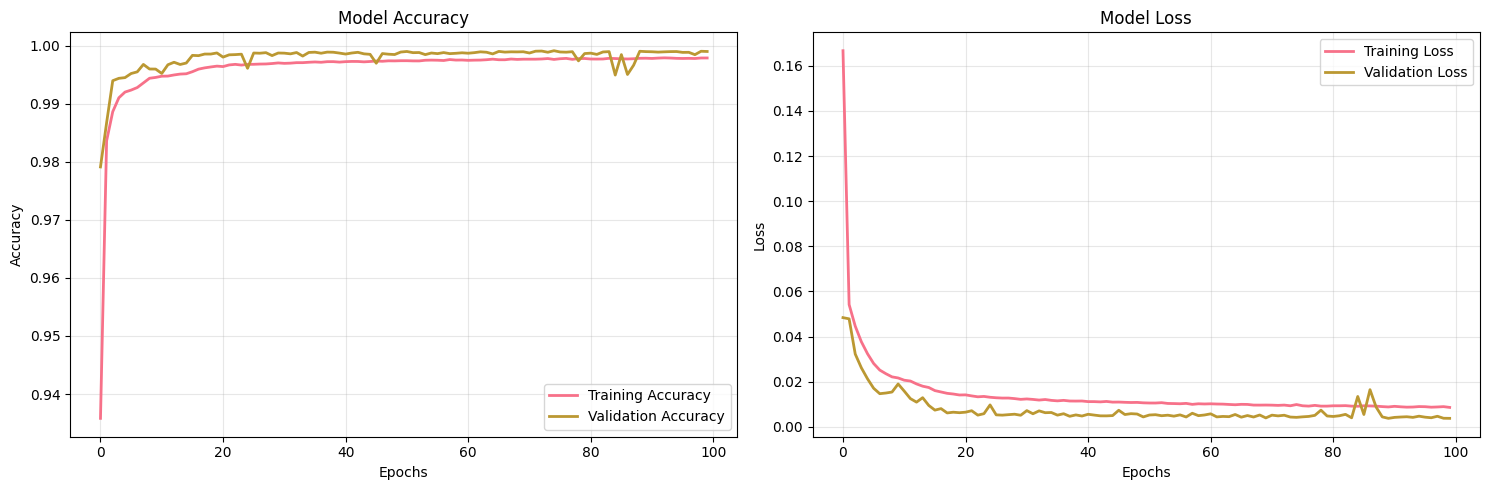

📊 Final Training Metrics:
   Training Accuracy: 0.9979
   Validation Accuracy: 0.9990
   Training Loss: 0.0086
   Validation Loss: 0.0038


In [ ]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.set_title('Model Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    print(f"📊 Final Training Metrics:")
    print(f"   Training Accuracy: {final_train_acc:.4f}")
    print(f"   Validation Accuracy: {final_val_acc:.4f}")
    print(f"   Training Loss: {final_train_loss:.4f}")
    print(f"   Validation Loss: {final_val_loss:.4f}")

# Plot training history
plot_training_history(history)

## 6. Model Evaluation Functions

In [ ]:
def evaluate_model(model, X_test, y_test, dataset_name, verbose=True):
    """
    Comprehensive model evaluation function
    Returns detailed metrics including F1, accuracy, TPR, TNR, FNR, FPR
    """
    # Predictions
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    
    # Calculate metrics
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    # Handle different confusion matrix sizes
    if cm.size == 4:  # 2x2 matrix (both classes present)
        tn, fp, fn, tp = cm.ravel()
    elif cm.size == 1:  # Only one class present
        if np.unique(y_test)[0] == 0:  # Only benign
            tn, fp, fn, tp = cm[0, 0], 0, 0, 0
        else:  # Only malicious
            tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
    else:
        tn = fp = fn = tp = 0
    
    # Calculate rates
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity/Recall
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    
    if verbose:
        print(f"\n📊 {dataset_name} Evaluation Results:")
        print(f"   Samples: {len(X_test)}")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   True Positive Rate (TPR/Recall): {tpr:.4f}")
        print(f"   True Negative Rate (TNR/Specificity): {tnr:.4f}")
        print(f"   False Negative Rate (FNR): {fnr:.4f}")
        print(f"   False Positive Rate (FPR): {fpr:.4f}")
        print(f"   Confusion Matrix:\n{cm}")
    
    return {
        'dataset': dataset_name,
        'samples': len(X_test),
        'f1': f1,
        'accuracy': accuracy,
        'tpr': tpr,
        'tnr': tnr,
        'fnr': fnr,
        'fpr': fpr,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'confusion_matrix': cm
    }

def load_test_dataset(dataset_path, dataset_name):
    """Load test dataset with error handling"""
    try:
        test_pattern = os.path.join(dataset_path, '*-test.hdf5')
        test_files = glob.glob(test_pattern)
        
        if not test_files:
            print(f"❌ No test files found for {dataset_name}")
            return None, None
            
        X_test, y_test = load_dataset(test_pattern)
        print(f"✅ Loaded {dataset_name}: {X_test.shape} samples")
        return X_test, y_test
        
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return None, None

print("🔧 Evaluation functions defined successfully")

🔧 Evaluation functions defined successfully


## 7. Three-Dataset FNR Comparison Analysis

Evaluate the trained MLP model on the three target datasets and analyze False Negative Rate (FNR) patterns:

1. **Baseline (FLATTEN-PCAPS)**: Original traffic data - serves as baseline performance
2. **Manipulated (MANIPULATED-FLATTEN_42)**: Traffic with manipulation techniques - tests robustness against traffic manipulation
3. **Fragmented (FRAGMENTED_42_150)**: Traffic with fragmentation techniques - tests robustness against packet fragmentation

This analysis will identify which attacks are most vulnerable to evasion techniques and compare the effectiveness of different evasion methods.

In [ ]:
# Overall Dataset Evaluation (for general performance overview)
print("🎯 Overall Dataset Performance Overview")
print("="*60)

# Load model (use trained model from memory)
evaluation_model = mlp_model

# Storage for overall results
overall_results = {}

# Evaluate each target dataset for overall performance
for dataset_key, dataset_info in TARGET_DATASETS.items():
    print(f"\n🔍 Evaluating: {dataset_info['name']} ({dataset_info['description']})")
    
    # Load test data
    X_test, y_test = load_test_dataset(dataset_info['path'], dataset_info['name'])
    
    if X_test is not None and y_test is not None:
        # Evaluate model
        results = evaluate_model(evaluation_model, X_test, y_test, dataset_info['name'])
        overall_results[dataset_key] = results
        
        print(f"   📊 Key Metrics - F1: {results['f1']:.4f}, FNR: {results['fnr']:.4f}, Accuracy: {results['accuracy']:.4f}")
    else:
        print(f"   ⚠️  Skipping {dataset_info['name']} - data not available")

print(f"\n✅ Overall evaluation completed: {len(overall_results)} datasets")

🎯 Overall Dataset Performance Overview

🔍 Evaluating: Baseline (Original traffic data (baseline))
✅ Loaded Baseline: (81887, 21) samples



📊 Baseline Evaluation Results:
   Samples: 81887
   F1 Score: 0.9991
   Accuracy: 0.9991
   True Positive Rate (TPR/Recall): 0.9987
   True Negative Rate (TNR/Specificity): 0.9995
   False Negative Rate (FNR): 0.0013
   False Positive Rate (FPR): 0.0005
   Confusion Matrix:
[[40981    22]
 [   54 40830]]
   📊 Key Metrics - F1: 0.9991, FNR: 0.0013, Accuracy: 0.9991

🔍 Evaluating: Manipulated (Traffic with manipulation techniques (seed 42))
✅ Loaded Manipulated: (31128, 21) samples

📊 Manipulated Evaluation Results:
   Samples: 31128
   F1 Score: 0.9922
   Accuracy: 0.9923
   True Positive Rate (TPR/Recall): 0.9934
   True Negative Rate (TNR/Specificity): 0.9911
   False Negative Rate (FNR): 0.0066
   False Positive Rate (FPR): 0.0089
   Confusion Matrix:
[[15479   139]
 [  102 15408]]
   📊 Key Metrics - F1: 0.9922, FNR: 0.0066, Accuracy: 0.9923

🔍 Evaluating: Fragmented (Traffic with fragmentation techniques (seed 42, 150 fragments))
✅ Loaded Fragmented: (100855, 21) samples

📊 Fragmen

## 8. Attack-Specific FNR Analysis

Detailed False Negative Rate (FNR) analysis for each attack type across the three datasets. This reveals:

- **Vulnerability patterns**: Which attacks are most susceptible to evasion techniques
- **Evasion effectiveness**: How manipulation vs fragmentation affects each attack type
- **Robustness insights**: Model performance degradation patterns per attack

In [ ]:
# Attack-specific FNR analysis
print("🎯 Attack-Specific FNR Analysis")
print("="*60)

# Storage for attack-specific results
attack_fnr_results = defaultdict(dict)
attack_evaluation_data = []

# Analyze each attack type across all datasets
for attack in ATTACK_TYPES:
    attack_name = attack.split('-', 1)[1] if '-' in attack else attack
    print(f"\n🔍 Analyzing: {attack_name}")
    
    for dataset_key, dataset_info in TARGET_DATASETS.items():
        attack_path = os.path.join(dataset_info['path'], attack)
        
        if not os.path.exists(attack_path):
            print(f"   ⚠️  {dataset_info['name']}: Attack folder not found")
            continue
        
        # Look for test files
        test_pattern = os.path.join(attack_path, '*test*.hdf5')
        test_files = glob.glob(test_pattern)
        
        if not test_files:
            print(f"   ⚠️  {dataset_info['name']}: No test files found")
            continue
            
        try:
            # Load attack-specific test data
            X_attack_test, y_attack_test = load_dataset(test_pattern)
            
            if len(X_attack_test) == 0:
                print(f"   ⚠️  {dataset_info['name']}: Empty dataset")
                continue
            
            # Evaluate model
            results = evaluate_model(evaluation_model, X_attack_test, y_attack_test, 
                                   f"{attack_name} - {dataset_info['name']}", verbose=False)
            
            # Store results
            attack_fnr_results[attack_name][dataset_key] = results
            
            # Store for DataFrame
            attack_evaluation_data.append({
                'Attack': attack_name,
                'Dataset': dataset_info['name'],
                'Dataset_Key': dataset_key,
                'FNR': results['fnr'],
                'F1': results['f1'],
                'Accuracy': results['accuracy'],
                'Samples': results['samples']
            })
            
            print(f"   ✅ {dataset_info['name']}: FNR={results['fnr']:.4f}, Samples={results['samples']}")
            
        except Exception as e:
            print(f"   ❌ {dataset_info['name']}: Error - {str(e)}")

print(f"\n✅ Attack analysis completed: {len(attack_fnr_results)} attacks analyzed")

🎯 Attack-Specific FNR Analysis

🔍 Analyzing: WebDDoS
   ✅ Baseline: FNR=0.0000, Samples=41
   ✅ Manipulated: FNR=0.1455, Samples=88
   ✅ Fragmented: FNR=0.0080, Samples=1313

🔍 Analyzing: LDAP
   ✅ Baseline: FNR=0.0127, Samples=153
   ✅ Manipulated: FNR=0.0052, Samples=388
   ✅ Fragmented: FNR=0.0061, Samples=237

🔍 Analyzing: Portmap
   ✅ Baseline: FNR=0.0000, Samples=18
   ✅ Manipulated: FNR=0.0031, Samples=7095
   ✅ Fragmented: FNR=0.0024, Samples=810

🔍 Analyzing: DNS
   ✅ Baseline: FNR=0.2432, Samples=61
   ✅ Manipulated: FNR=0.1387, Samples=506
   ✅ Fragmented: FNR=0.2615, Samples=147

🔍 Analyzing: UDPLag
   ✅ Baseline: FNR=0.0000, Samples=130
   ✅ Manipulated: FNR=0.0068, Samples=3074
   ✅ Fragmented: FNR=0.0244, Samples=2475

🔍 Analyzing: NTP
   ✅ Baseline: FNR=0.0028, Samples=681
   ✅ Manipulated: FNR=0.1410, Samples=297
   ✅ Fragmented: FNR=0.0198, Samples=1365

🔍 Analyzing: SNMP
   ✅ Baseline: FNR=0.0000, Samples=513
   ✅ Manipulated: FNR=0.0046, Samples=4740
   ✅ Fragmented

## 9. FNR Comparison Table 

Comprehensive FNR comparison table showing values for each attack type across all three datasets, with performance degradation analysis and summary statistics.

In [ ]:
# Create comprehensive FNR comparison table
if attack_evaluation_data:
    # Convert to DataFrame
    fnr_df = pd.DataFrame(attack_evaluation_data)
    
    # Create pivot table for FNR comparison
    fnr_pivot = fnr_df.pivot(index='Attack', columns='Dataset', values='FNR')
    
    # Reorder attacks according to ATTACK_TYPES order (00-WebDDoS, 01-LDAP, etc.)
    attack_order = [attack.split('-', 1)[1] if '-' in attack else attack for attack in ATTACK_TYPES]
    
    # Filter to only include attacks that exist in our data and reorder
    existing_attacks = [attack for attack in attack_order if attack in fnr_pivot.index]
    fnr_pivot_ordered = fnr_pivot.reindex(existing_attacks)
    
    # Round for better display
    fnr_pivot_ordered = fnr_pivot_ordered.round(4)
    
    print("📊 FNR COMPARISON TABLE - EXACT VALUES")
    print("=" * 70)
    print("Rows = Attacks (in folder order), Columns = Datasets")
    print("=" * 70)
    print(fnr_pivot_ordered.to_string())
    
    # Summary statistics - averages per dataset (columns)
    print(f"\n📈 SUMMARY STATISTICS:")
    
    for dataset in fnr_pivot_ordered.columns:
        dataset_avg = fnr_pivot_ordered[dataset].mean()
        print(f"   Average {dataset} FNR: {dataset_avg:.4f}")
    
    # Find highest and lowest FNR values per dataset
    print(f"\n🔍 FNR ANALYSIS:")
    
    for dataset in fnr_pivot_ordered.columns:
        max_fnr_attack = fnr_pivot_ordered[dataset].idxmax()
        min_fnr_attack = fnr_pivot_ordered[dataset].idxmin()
        max_fnr_value = fnr_pivot_ordered[dataset].max()
        min_fnr_value = fnr_pivot_ordered[dataset].min()
        
        print(f"\n   {dataset} Dataset:")
        print(f"      Highest FNR: {max_fnr_attack} ({max_fnr_value:.4f})")
        print(f"      Lowest FNR:  {min_fnr_attack} ({min_fnr_value:.4f})")

else:
    print("❌ No attack evaluation data available for comparison table")

📊 FNR COMPARISON TABLE - EXACT VALUES
Rows = Attacks (in folder order), Columns = Datasets
Dataset  Baseline  Fragmented  Manipulated
Attack                                    
WebDDoS    0.0000      0.0080       0.1455
LDAP       0.0127      0.0061       0.0052
Portmap    0.0000      0.0024       0.0031
DNS        0.2432      0.2615       0.1387
UDPLag     0.0000      0.0244       0.0068
NTP        0.0028      0.0198       0.1410
SNMP       0.0000      0.0204       0.0046
SSDP       0.0015      0.0000       0.0000
Syn        0.0000      0.0000       0.0000
TFTP       0.0000      0.0000       0.0005
UDP        0.0000      0.0955       0.0000
NetBIOS    0.0038      0.0183       0.0000
MSSQL      0.0001      0.0000       0.0000

📈 SUMMARY STATISTICS:
   Average Baseline FNR: 0.0203
   Average Fragmented FNR: 0.0351
   Average Manipulated FNR: 0.0343

🔍 FNR ANALYSIS:

   Baseline Dataset:
      Highest FNR: DNS (0.2432)
      Lowest FNR:  WebDDoS (0.0000)

   Fragmented Dataset:
      Hig

## 10. FNR Visualization and Results Table

Visual analysis of FNR patterns across attacks and datasets with comprehensive comparison table.

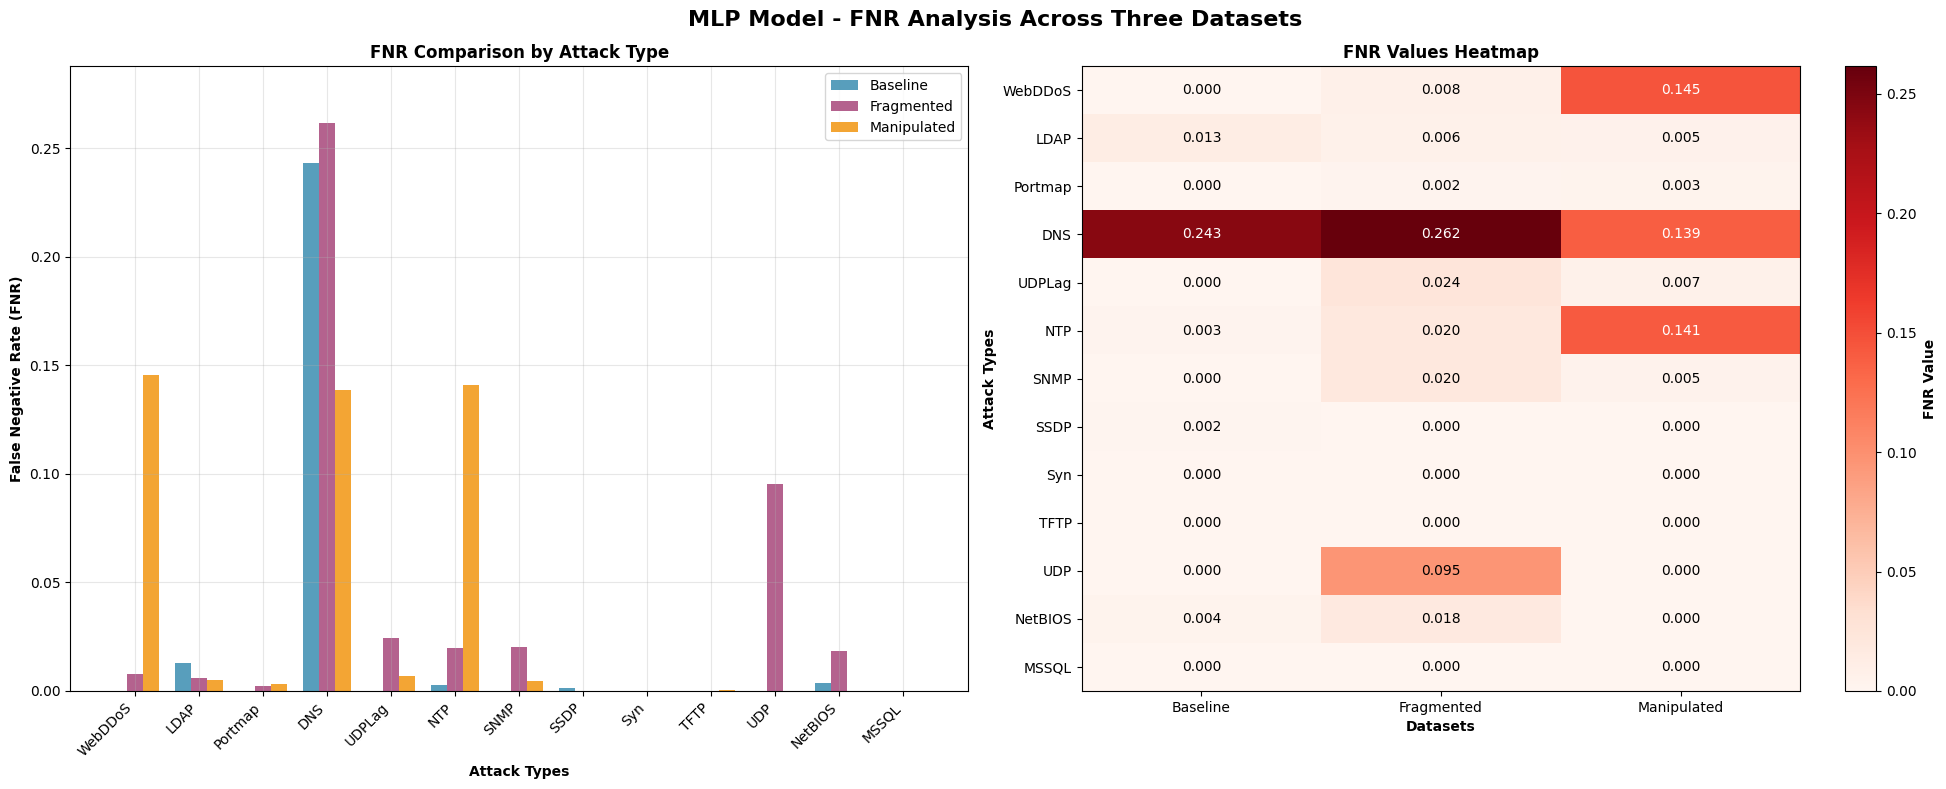


📋 FINAL FNR COMPARISON TABLE
Dataset Analysis: FLATTEN-PCAPS (Baseline) vs MANIPULATED-FLATTEN_42 vs FRAGMENTED_42_150
Metric: False Negative Rate (FNR) - Lower values indicate better performance
Dataset  Baseline  Fragmented  Manipulated
Attack                                    
WebDDoS    0.0000      0.0080       0.1455
LDAP       0.0127      0.0061       0.0052
Portmap    0.0000      0.0024       0.0031
DNS        0.2432      0.2615       0.1387
UDPLag     0.0000      0.0244       0.0068
NTP        0.0028      0.0198       0.1410
SNMP       0.0000      0.0204       0.0046
SSDP       0.0015      0.0000       0.0000
Syn        0.0000      0.0000       0.0000
TFTP       0.0000      0.0000       0.0005
UDP        0.0000      0.0955       0.0000
NetBIOS    0.0038      0.0183       0.0000
MSSQL      0.0001      0.0000       0.0000

📈 SUMMARY ANALYSIS:
Dataset         Avg FNR    Min FNR    Max FNR    Worst Attack   
----------------------------------------------------------------------
B

In [ ]:
# Comprehensive FNR Visualization and Results Table
if attack_evaluation_data and len(fnr_pivot) > 0:
    
    # Reorder attacks according to ATTACK_TYPES order
    attack_order = [attack.split('-', 1)[1] if '-' in attack else attack for attack in ATTACK_TYPES]
    existing_attacks = [attack for attack in attack_order if attack in fnr_pivot.index]
    fnr_pivot_ordered = fnr_pivot.reindex(existing_attacks)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('MLP Model - FNR Analysis Across Three Datasets', fontsize=16, fontweight='bold')
    
    # 1. FNR Comparison Bar Chart
    ax1 = axes[0]
    available_datasets = [col for col in fnr_pivot_ordered.columns if col in ['Baseline', 'Manipulated', 'Fragmented']]
    
    x = np.arange(len(fnr_pivot_ordered.index))  # Attack positions
    width = 0.25
    colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    
    for i, dataset in enumerate(available_datasets):
        values = fnr_pivot_ordered[dataset].fillna(0).values
        ax1.bar(x + i*width, values, width, label=dataset, color=colors[i % len(colors)], alpha=0.8)
    
    ax1.set_xlabel('Attack Types', fontweight='bold')
    ax1.set_ylabel('False Negative Rate (FNR)', fontweight='bold')
    ax1.set_title('FNR Comparison by Attack Type', fontweight='bold')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels(fnr_pivot_ordered.index, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max(fnr_pivot_ordered.max().max() * 1.1, 0.1))
    
    # 2. FNR Values Heatmap
    ax2 = axes[1]
    heatmap_data = fnr_pivot_ordered[available_datasets]
    im = ax2.imshow(heatmap_data.values, cmap='Reds', aspect='auto')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('FNR Value', fontweight='bold')
    
    ax2.set_title('FNR Values Heatmap', fontweight='bold')
    ax2.set_xlabel('Datasets', fontweight='bold')
    ax2.set_ylabel('Attack Types', fontweight='bold')
    ax2.set_xticks(range(len(heatmap_data.columns)))
    ax2.set_xticklabels(heatmap_data.columns, rotation=0, ha='center')
    ax2.set_yticks(range(len(heatmap_data.index)))
    ax2.set_yticklabels(heatmap_data.index)
    
    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not pd.isna(value):
                text = ax2.text(j, i, f'{value:.3f}',
                              ha="center", va="center", 
                              color="white" if value > heatmap_data.values.max()/2 else "black")
    
    plt.tight_layout()
    plt.show()
    
    # Create Final Results Table
    print("\n" + "="*90)
    print("📋 FINAL FNR COMPARISON TABLE")
    print("="*90)
    print("Dataset Analysis: FLATTEN-PCAPS (Baseline) vs MANIPULATED-FLATTEN_42 vs FRAGMENTED_42_150")
    print("Metric: False Negative Rate (FNR) - Lower values indicate better performance")
    print("="*90)
    
    # Display the ordered FNR table
    display_df = fnr_pivot_ordered[available_datasets]
    print(display_df.round(4).to_string())
    
    # Summary Analysis
    print(f"\n📈 SUMMARY ANALYSIS:")
    print(f"{'Dataset':<15} {'Avg FNR':<10} {'Min FNR':<10} {'Max FNR':<10} {'Worst Attack':<15}")
    print("-" * 70)
    
    for dataset in available_datasets:
        avg_fnr = display_df[dataset].mean()
        min_fnr = display_df[dataset].min()
        max_fnr = display_df[dataset].max()
        worst_attack = display_df[dataset].idxmax()
        print(f"{dataset:<15} {avg_fnr:<10.4f} {min_fnr:<10.4f} {max_fnr:<10.4f} {worst_attack:<15}")
    
    # Performance degradation analysis
    if 'Baseline' in available_datasets:
        print(f"\n🔍 EVASION TECHNIQUE EFFECTIVENESS:")
        baseline_avg = display_df['Baseline'].mean()
        
        for dataset in available_datasets:
            if dataset != 'Baseline':
                dataset_avg = display_df[dataset].mean()
                degradation = ((dataset_avg - baseline_avg) / baseline_avg) * 100
                print(f"   {dataset} vs Baseline: {degradation:+.1f}% FNR change (avg)")
    
else:
    print("❌ No FNR data available for visualization")

print(f"\n✅ FNR Analysis Complete - Three-dataset comparison finished")

In [4]:
# Print metrics for the Fragmented dataset
if 'FRAGMENTED_42_150' in overall_results:
    fragmented_results = overall_results['FRAGMENTED_42_150']
    print("📊 FRAGMENTED_42_150 Dataset Metrics:")
    print(f"   F1 Score: {fragmented_results['f1']:.4f}")
    print(f"   False Negative Rate (FNR): {fragmented_results['fnr']:.4f}")
    print(f"   Accuracy: {fragmented_results['accuracy']:.4f}")
else:
    print("❌ Fragmented dataset results not found in overall_results")

NameError: name 'overall_results' is not defined